# Chapter 3 — goodness-of-fit main-text figures

Single metric: **Mahalanobis $\chi^2/N$** (Sec. *Goodness-of-Fit Metric*),
shown in its two covariance budgets:

- **full covariance** $\sigma_{\mathrm{exp}}\oplus\sigma_{\mathrm{eval}}$ — rank-2 EXFOR systematics **+** dense `MF34` block (internal label `V4`)
- **EXFOR only** $\sigma_{\mathrm{exp}}$ — `MF34` removed (internal label `V2`)

Only the figures that appear in the chapter main text are produced here. The
diagnostic variants (diagonal-only, `MF34`-diagonal-only) and every appendix /
supplementary plot live in `manuscript/CHAPTER-3/chi2_analysis/make_chi2_figures.ipynb`.

Reads precomputed `run_079` results from the mounted cluster share. This run
applies **per-energy systematic blocking** to the EXFOR-c0 methodology: because
$c_0$ is fit independently at each incident energy, the EXFOR normalization/shape
rank-2 modes are masked block-diagonal per energy, so they no longer penalise the
energy-to-energy level differences the per-energy fit has already removed. The
diagonal budget (`V1`) is unchanged; the correlated budgets (`V2`/`V3`/`V4`) drop.
**No figures are written to disk**: each cell renders inline; save manually from
the notebook.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Precomputed chi-squared results (EXFOR-c0 methodology, run_079).
# run_079 applies per-energy systematic blocking (systematic_block_col='energy_mev'):
# the EXFOR normalization/shape rank-2 modes are masked block-diagonal per incident
# energy, so they no longer penalise the energy-to-energy level differences the
# per-energy c0 fit already removed. V1 (diagonal) is unchanged; V2/V3/V4 drop.
RUN_DIR = Path('/share_snc/snc/JuanMonleon/CHI_Figures/chi2_exfor_c0/run_079')

plt.rcParams.update({
    'figure.dpi': 110,
    'font.size': 10,
    'axes.titlesize': 11,
    'axes.labelsize': 10,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.25,
    'grid.linestyle': '--',
    'legend.frameon': False,
})

# Thesis library palette: JEFF/JENDL from the kika colorblind set, this work in red.
COLOR = {
    'JEFF-4.0':  '#0173B2',
    'JENDL-5':   '#029E73',
    'This work': '#D62728',
}
LIBS = ['JEFF-4.0', 'JENDL-5', 'This work']
LIB_RAW_TO_DISPLAY = {'JEFF': 'JEFF-4.0', 'JENDL': 'JENDL-5', 'This_work': 'This work'}

SUBSETS = [
    ('all',                'All experiments'),
    ('no_Cierjacks',       'Excluding Cierjacks 1978'),
    ('no_KS',              'Excluding Kinney & Smith'),
    ('no_KS_no_Cierjacks', 'Excluding K&S and Cierjacks'),
    ('only_KS',            'Kinney & Smith only'),
    ('only_Cierjacks',     'Cierjacks only'),
]

# The single metric, in its two covariance budgets. PRIMARY (full covariance) is
# reported throughout the section; COMPANION (EXFOR only) is its MF34-removed
# counterpart, shown only for the subset panel.
PRIMARY   = 'V4'
COMPANION = 'V2'
BUDGET_NAME = {'V4': 'full covariance', 'V2': 'EXFOR only'}
VARIANT_TITLE = {
    'V4': r'Full covariance ($\sigma_{\mathrm{exp}}\oplus\sigma_{\mathrm{eval}}$)',
    'V2': r'EXFOR only, MF34 removed ($\sigma_{\mathrm{exp}}$)',
}

In [2]:
with (RUN_DIR / 'summary.json').open() as fh:
    SUMMARY = json.load(fh)

def col(lib_raw, variant):
    return f'{lib_raw}_{variant}'

def subset_total(sub_key, lib_disp, variant):
    for r in SUMMARY['per_subset_all_variants'][sub_key]:
        if r['Library'] == lib_disp:
            return r[f'chi2_{variant.lower()}_per_N']
    raise KeyError(f'{sub_key} / {lib_disp}')

def subset_N(sub_key):
    return SUMMARY['per_subset_all_variants'][sub_key][0]['N']

def win_tally_for(variant):
    return {
        r['Library']: {'best':  r[f'{variant} best'],
                       'mid':   r[f'{variant} mid'],
                       'worst': r[f'{variant} worst']}
        for r in SUMMARY['win_tally_per_subset']['all']
    }

print('Experiments in pool:', SUMMARY['n_experiments'])
print('\nHeadline chi2/N on the full pool:')
for v in (PRIMARY, COMPANION):
    print(f'  [{BUDGET_NAME[v]}]')
    for lib in LIBS:
        print(f'    {lib:<10s}  {subset_total("all", lib, v):8.2f}')

Experiments in pool: 67

Headline chi2/N on the full pool:
  [full covariance]
    JEFF-4.0       20.51
    JENDL-5        25.45
    This work       8.48
  [EXFOR only]
    JEFF-4.0       33.29
    JENDL-5        33.56
    This work      16.87


In [3]:
PER_EXP = {sub: pd.read_csv(RUN_DIR / 'per_experiment' / f'per_experiment_{sub}.csv')
           for sub, _ in SUBSETS}
print({k: len(v) for k, v in PER_EXP.items()})
PER_EXP['all'].head()

{'all': 67, 'no_Cierjacks': 66, 'no_KS': 65, 'no_KS_no_Cierjacks': 64, 'only_KS': 2, 'only_Cierjacks': 1}


,experiment_id,author,year,E_min,E_max,JEFF_V1,JENDL_V1,This_work_V1,JEFF_V2,JENDL_V2,This_work_V2,JEFF_V3,JENDL_V3,This_work_V3,JEFF_V4,JENDL_V4,This_work_V4,N
0,20482005,Cabe,1967,0.9700,0.9700,65.487810,17.240694,2.464583,3025.815968,5524.215199,253.634899,76.452368,15.842010,2.574338,103.362588,1799.431263,15.600075,11
1,20008013,Tomita,1973,1.9400,1.9400,28.353739,8.985942,2.755634,1609.379365,3136.343832,96.345891,32.063753,10.737608,6.231231,21.384702,737.053299,7.730826,14
2,20008004,Tomita,1973,1.5560,1.5560,8.630458,11.518812,2.363013,1151.624852,1640.893437,42.078992,10.404844,17.923288,2.392941,56.501708,558.181362,13.133726,13
3,10332004,Cox,1972,0.9021,0.9021,10.618545,4.949222,2.902461,796.844610,1610.375959,157.446027,15.672513,4.820627,6.522939,67.574771,241.728127,42.235436,8
4,20008003,Tomita,1973,1.4700,1.4700,203.450326,11.903853,7.116913,102.289864,1414.416803,208.587498,40.996295,17.112073,21.232517,30.210149,360.590892,12.873678,13


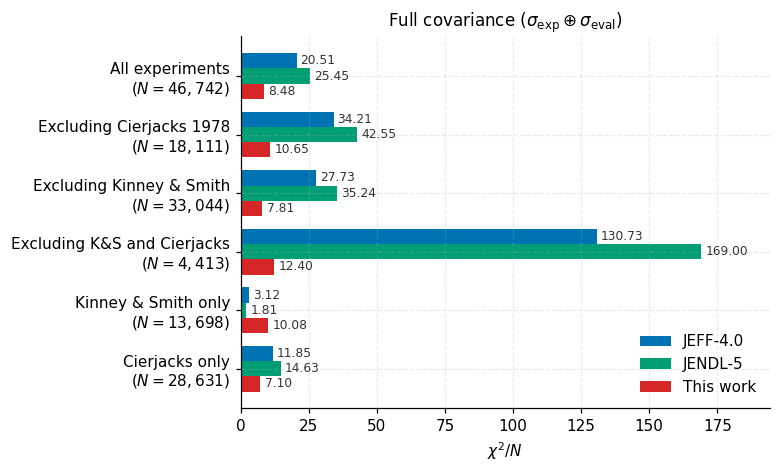

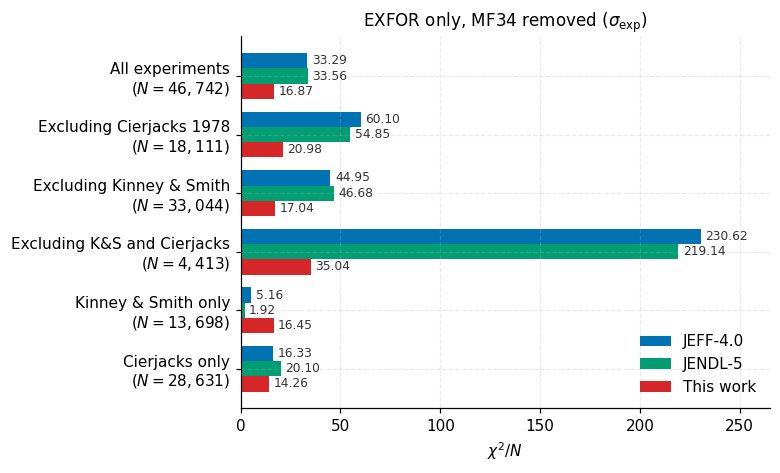

In [4]:
# Subset panel — both covariance budgets (manuscript fig:chi2_v4_summary + fig:chi2_v2_summary).
subset_keys   = [s[0] for s in SUBSETS]
subset_labels = [s[1] for s in SUBSETS]

for variant in (PRIMARY, COMPANION):
    fig, ax = plt.subplots(figsize=(7.2, 4.4))
    y_pos = np.arange(len(SUBSETS))
    bar_h = 0.26
    max_val = 0.0
    for i, lib in enumerate(LIBS):
        vals = [subset_total(sub, lib, variant) for sub in subset_keys]
        max_val = max(max_val, max(vals))
        bars = ax.barh(y_pos + (i - 1) * bar_h, vals, height=bar_h,
                       color=COLOR[lib], label=lib)
        for bar, val in zip(bars, vals):
            ax.text(val + max_val * 0.01, bar.get_y() + bar.get_height() / 2,
                    f'{val:.2f}', va='center', fontsize=8, color='#333')
    ns = [subset_N(sub) for sub in subset_keys]
    ax.set_yticks(y_pos)
    ax.set_yticklabels([f'{lab}\n($N={n:,}$)' for lab, n in zip(subset_labels, ns)])
    ax.invert_yaxis()
    ax.set_xlabel(r'$\chi^2/N$')
    ax.set_xlim(0, max_val * 1.15)
    ax.set_title(VARIANT_TITLE[variant])
    ax.legend(loc='lower right')
    fig.tight_layout()
    plt.show()

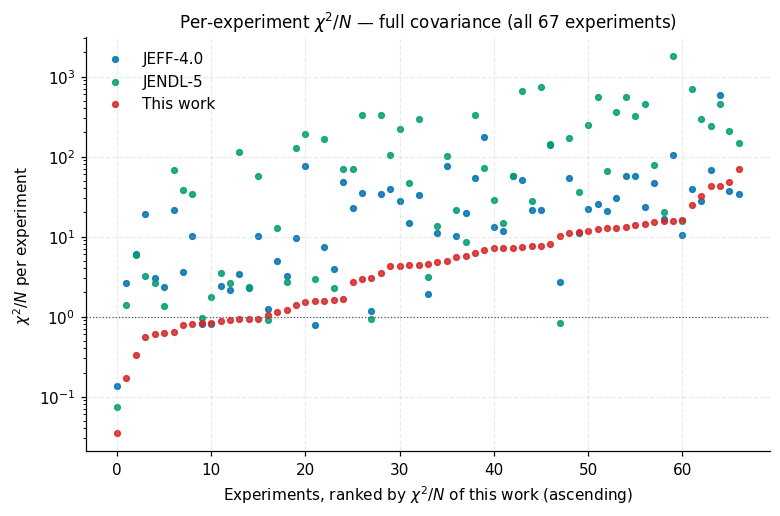

In [5]:
# Per-experiment strip, all 67 experiments (manuscript fig:chi2_v4_perexp_strip).
variant = PRIMARY
df = PER_EXP['all'].sort_values(col('This_work', variant)).reset_index(drop=True)
rank = np.arange(len(df))

fig, ax = plt.subplots(figsize=(7.2, 4.8))
for lib_raw, lib_disp in LIB_RAW_TO_DISPLAY.items():
    ax.scatter(rank, df[col(lib_raw, variant)],
               color=COLOR[lib_disp], s=14, alpha=0.85, label=lib_disp)
ax.set_yscale('log')
ax.axhline(1, color='#555', lw=0.8, linestyle=':')
ax.set_xlabel(r'Experiments, ranked by $\chi^2/N$ of this work (ascending)')
ax.set_ylabel(r'$\chi^2/N$ per experiment')
ax.set_title(f'Per-experiment $\\chi^2/N$ — {BUDGET_NAME[variant]} (all {len(df)} experiments)')
ax.legend(loc='upper left')
fig.tight_layout()
plt.show()

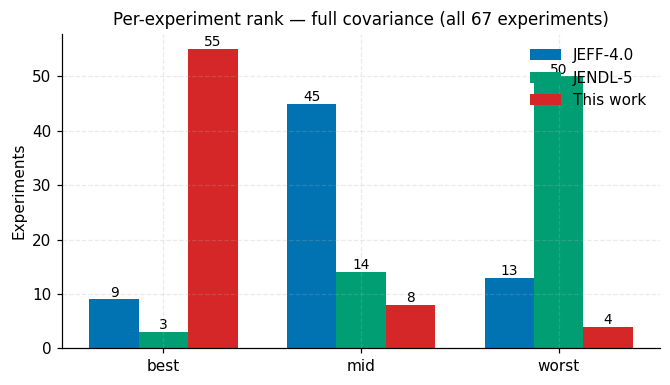

In [6]:
# Per-experiment win-tally, all 67 experiments (manuscript fig:chi2_v4_wintally).
variant = PRIMARY
wins = win_tally_for(variant)
n_exp = sum(wins['JEFF-4.0'].values())

fig, ax = plt.subplots(figsize=(6.2, 3.6))
bar_w = 0.25
for i, lib in enumerate(LIBS):
    xs = np.array([0, 1, 2]) + (i - 1) * bar_w
    ys = [wins[lib]['best'], wins[lib]['mid'], wins[lib]['worst']]
    bars = ax.bar(xs, ys, width=bar_w, color=COLOR[lib], label=lib)
    for bar, y in zip(bars, ys):
        ax.text(bar.get_x() + bar.get_width() / 2, y + 0.5, str(int(y)),
                ha='center', fontsize=9)
ax.set_xticks([0, 1, 2])
ax.set_xticklabels(['best', 'mid', 'worst'])
ax.set_ylabel('Experiments')
ax.set_title(f'Per-experiment rank — {BUDGET_NAME[variant]} (all {n_exp} experiments)')
ax.legend(loc='upper right')
fig.tight_layout()
plt.show()

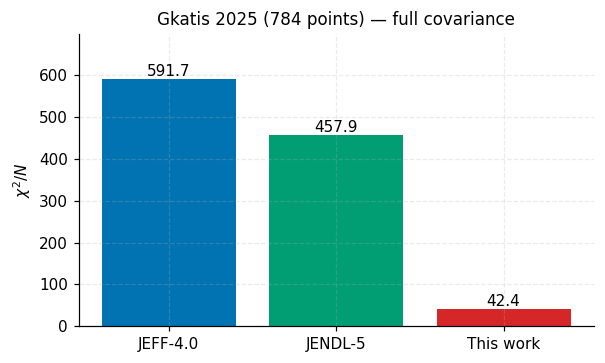

In [7]:
# Gkatis 2025 out-of-sample case study (manuscript fig:chi2_gkatis_v4).
variant = PRIMARY
GKATIS_ID = '27673002'
gkatis = PER_EXP['all'][PER_EXP['all']['experiment_id'].astype(str) == GKATIS_ID].iloc[0]

fig, ax = plt.subplots(figsize=(5.6, 3.4))
vals = [gkatis[col(lib_raw, variant)] for lib_raw in LIB_RAW_TO_DISPLAY]
colors = [COLOR[LIB_RAW_TO_DISPLAY[lib_raw]] for lib_raw in LIB_RAW_TO_DISPLAY]
bars = ax.bar(LIBS, vals, color=colors)
for bar, val in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width() / 2, val,
            f'{val:.1f}', ha='center', va='bottom', fontsize=10)
ax.set_ylabel(r'$\chi^2/N$')
ax.set_ylim(0, max(vals) * 1.18)
ax.set_title(f'Gkatis 2025 ({int(gkatis["N"])} points) — {BUDGET_NAME[variant]}')
fig.tight_layout()
plt.show()

In [8]:
# Verification — the rendered full-covariance values match the numbers quoted in
# the chapter prose (so the figures show the chosen metric, not a diagnostic variant).
# run_079 (per-energy systematic blocking): full pool dropped from 13.7/29.6/38.0.
def chk(name, got, exp):
    ok = abs(got - exp) <= max(0.1, 0.01 * abs(exp))
    print(f"  {'ok ' if ok else 'XX '}{name:<10s} got {got:8.2f}   expected {exp:8.2f}")
    assert ok, f'{name}: {got} != {exp}'

print('Full pool, full covariance (chapter: 8.5 / 20.5 / 25.4):')
chk('This work', subset_total('all', 'This work', PRIMARY), 8.5)
chk('JEFF-4.0',  subset_total('all', 'JEFF-4.0',  PRIMARY), 20.5)
chk('JENDL-5',   subset_total('all', 'JENDL-5',   PRIMARY), 25.4)

# Gkatis is a single-energy experiment (one block = global), so blocking is a
# no-op there: these values are identical to the pre-fix run.
print('Gkatis 2025, full covariance (chapter: 42.4 / 591.7 / 457.9):')
chk('This work', float(gkatis[col('This_work', PRIMARY)]), 42.4)
chk('JEFF-4.0',  float(gkatis[col('JEFF', PRIMARY)]),      591.7)
chk('JENDL-5',   float(gkatis[col('JENDL', PRIMARY)]),     457.9)

print('\nAll checks passed.')

Full pool, full covariance (chapter: 8.5 / 20.5 / 25.4):
  ok This work  got     8.48   expected     8.50
  ok JEFF-4.0   got    20.51   expected    20.50
  ok JENDL-5    got    25.45   expected    25.40
Gkatis 2025, full covariance (chapter: 42.4 / 591.7 / 457.9):
  ok This work  got    42.37   expected    42.40
  ok JEFF-4.0   got   591.70   expected   591.70
  ok JENDL-5    got   457.92   expected   457.90

All checks passed.
